# gCastle API Overview

This notebook explores the core APIs and components of gCastle,
a causal structure learning toolchain by Huawei Noah's Ark Lab.

We'll learn how to:
- Generate synthetic causal data with known ground truth
- Run various causal discovery algorithms
- Evaluate results using standard metrics
- Visualize learned causal structures

## Setup

In [29]:
# Load extension for auto-reload on edit.
%load_ext autoreload
%autoreload 2
%matplotlib inline

import logging
import warnings

logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import helpers.hnotebook as hnotebo

hnotebo.config_notebook()

In [31]:
import castle

print(castle.__name__)
print("Version:", castle.__version__)

castle
Version: 1.0.4


In [32]:
import tutorials.gCastle.gCastle_utils as tgcasti

## Cell 1: Data Generation

gCastle provides utilities to generate synthetic causal data with known DAGs.
This is essential for testing and validating causal discovery algorithms.

In [35]:
# Generate synthetic data with interactive parameters.
data, true_dag = tgcasti.cell1_data_generation_interactive()

# print(f"\nGenerated data shape: {data.shape}")
# print(f"Data columns: {list(data.columns)}")
# print(f"\nTrue DAG adjacency matrix:")
# print(true_dag)

INFO:root:Finished synthetic dataset


In [ ]:
# The DAG visualization is shown interactively in the previous cell.

## Cell 2: Constraint-Based Algorithm (PC)

The PC (Peter-Clark) algorithm is a constraint-based approach that uses
conditional independence tests to discover causal relationships. The key
parameter is **alpha** (significance level): higher values → fewer edges detected.</cell_type="markdown">
</invoke>

In [8]:
tgcasti.cell2_pc_algorithm_interactive(data.values, true_dag)

In [9]:
# Compute PC metrics with default alpha for later use
pc_adjacency = tgcasti.run_pc_algorithm(data.values, alpha=0.05)
pc_metrics = tgcasti.evaluate_causal_discovery(true_dag, pc_adjacency)

## Cell 3: Score-Based Algorithm (GES)

GES (Greedy Equivalence Search) uses a score-based approach,
optimizing a score function over equivalence classes.

Label(value='GES Algorithm: Score-Based Causal Discovery')

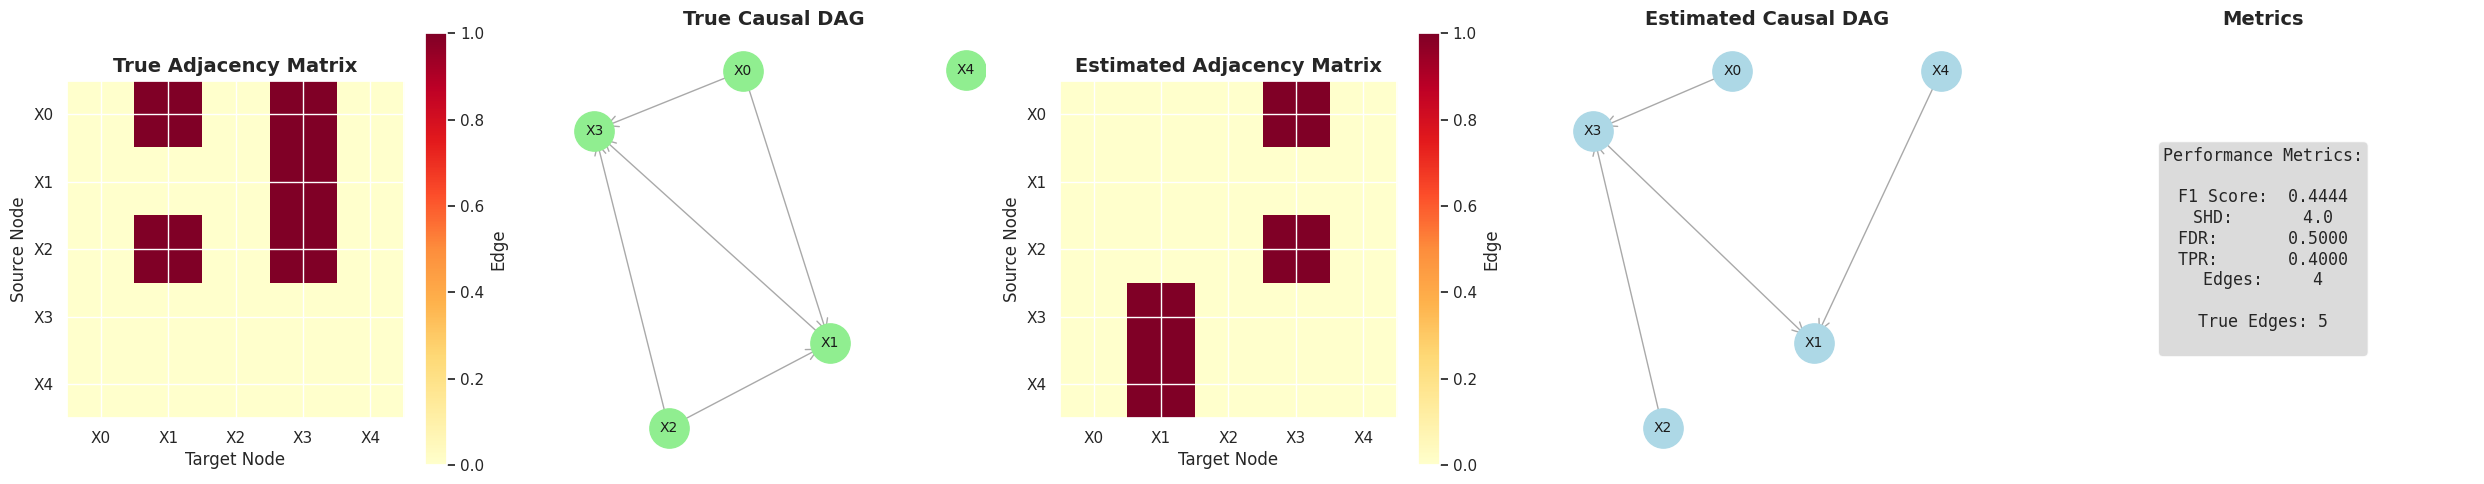

In [20]:
# Run the GES algorithm.
ges_adjacency = tgcasti.run_ges_algorithm(data.values)
ges_metrics = tgcasti.evaluate_causal_discovery(true_dag, ges_adjacency)

tgcasti.cell3_ges_algorithm_interactive(data.values, true_dag)

In [11]:
# Metrics already computed in previous cell - shown in visualization above

## Cell 4: Gradient-Based Algorithms

NOTEARS (No-Tears) and GOLEM are modern gradient-based algorithms
that can handle large-scale problems efficiently.

In [21]:
# Run NOTEARS algorithm with L2 loss (linear relationships).
notears_adjacency = tgcasti.run_notears_algorithm(
    data.values,
    lambda1=0.0,
    loss_type="l2",
)
notears_metrics = tgcasti.evaluate_causal_discovery(true_dag, notears_adjacency)

tgcasti.cell4_notears_algorithm_interactive(data.values, true_dag)

INFO:root:[start]: n=500, d=5, iter_=100, h_=1e-08, rho_=1e+16
INFO:root:[iter 0] h=2.901e-01, loss=7.158, rho=1.0e+00
INFO:root:[iter 1] h=2.164e-01, loss=1.704, rho=1.0e+00
INFO:root:[iter 1] h=1.140e-01, loss=2.083, rho=1.0e+01
INFO:root:[iter 1] h=4.269e-02, loss=5.870, rho=1.0e+02
INFO:root:[iter 2] h=2.544e-02, loss=2.165, rho=1.0e+02
INFO:root:[iter 2] h=9.646e-03, loss=2.986, rho=1.0e+03
INFO:root:[iter 3] h=5.601e-03, loss=2.316, rho=1.0e+03
INFO:root:[iter 3] h=2.060e-03, loss=2.735, rho=1.0e+04
INFO:root:[iter 4] h=1.194e-03, loss=2.383, rho=1.0e+04
INFO:root:[iter 4] h=4.443e-04, loss=2.574, rho=1.0e+05
INFO:root:[iter 5] h=2.606e-04, loss=2.414, rho=1.0e+05
INFO:root:[iter 5] h=9.828e-05, loss=2.503, rho=1.0e+06
INFO:root:[iter 6] h=5.768e-05, loss=2.429, rho=1.0e+06
INFO:root:[iter 6] h=2.155e-05, loss=2.473, rho=1.0e+07
INFO:root:[iter 7] h=1.266e-05, loss=2.437, rho=1.0e+07
INFO:root:[iter 7] h=4.768e-06, loss=2.457, rho=1.0e+08
INFO:root:[iter 8] h=2.818e-06, loss=2.44